# Config & Import

In [1]:
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import pickle
import copy
from pathlib import Path
import pandas as pd


# ===== IMPORTANT CONFIGURATION VARIABLES =====
input_dataset_type = "preprocessed"
output_dataset_type = "augmented"
dataset_split = 'training'  # can be 'training', 'validation', 'test'

# Function to find project root
def find_project_root(name='Bambino', start=None):
    if start is None:
        start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name:
            return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir:
            return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
print('Detected project root:', PROJECT_ROOT)

# Attempt to import config & datasets if project is found
dataset = None
dataset_original = None
if PROJECT_ROOT:
    try:
        sys.path.append(PROJECT_ROOT)
        from config import settings as utils
        from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
        print('Imported project modules successfully.')
        # try to load a sample split (this will only work if utils paths are correct locally)
        try:
            in_path = utils.get_dataset_path(input_dataset_type,
                                            getattr(utils, f'{dataset_split}_filename'))
            print('Attempting to load dataset from:', in_path)
            dataset = BoaOpenFaceDataset.load_dataset(in_path, modalities=None)
            dataset_original = BoaOpenFaceDataset.load_dataset(in_path, modalities=None)
            print('Dataset loaded:', type(dataset), 'instances:', len(dataset.instances))
            out_path = utils.get_dataset_path(output_dataset_type, getattr(utils, f'{dataset_split}_filename'))
            print(f'Output path for {output_dataset_type} dataset:', out_path)
        except Exception as e:
            print('Could not load dataset from project paths. Error:', e)
            dataset = None
    except Exception as e:
        print('Could not import project modules (thi). Error:', e)
        dataset = None


Detected project root: /home/phd2/Scrivania/CorsoRepo/Bambino
Imported project modules successfully.
Attempting to load dataset from: /home/phd2/Scrivania/CorsoRepo/Bambino/data/preprocessed/training_set.pt
Dataset loaded: <class 'DataUtils.BoaOpenFaceDataset.BoaOpenFaceDataset'> instances: 619
Output path for augmented dataset: /home/phd2/Scrivania/CorsoRepo/Bambino/data/augmented/training_set.pt


In [22]:
# ---------- Configuration ----------
TARGET_LEN = 250         # 10 s @ 25 Hz
ORIGINAL_POS_PER_TRIAL = 4  # how many original positives per trial (usually 1)
ORIGINAL_NEG_PER_TRIAL = 1  # how many original negatives per trial

balance_data = True    # set to True to balance pos/neg samples via augmentation
balance_ratio = 2      # moltiplicative factor

if balance_data and balance_ratio > 0:
    POS_AUG_PER_TRIAL = balance_ratio - 1 # how many positive augmentations per original positive
    NEG_AUG_PER_TRIAL = int( ((ORIGINAL_POS_PER_TRIAL * balance_ratio)-ORIGINAL_NEG_PER_TRIAL) / ORIGINAL_NEG_PER_TRIAL) # how many negative augmentations per original negative
else:
    POS_AUG_PER_TRIAL = 0    # default value if not balancing
    NEG_AUG_PER_TRIAL = 3    # default value if not balancing

print(f"Augmentation Configuration: POS_AUG_PER_TRIAL={POS_AUG_PER_TRIAL}, NEG_AUG_PER_TRIAL={NEG_AUG_PER_TRIAL}")

SAVE_PROCESSED = True   # set True to pickle the augmented dataset to out_path
PLOT_EXAMPLES = True     # show a few visualization examples
OUT_PATH = Path(out_path) if 'out_path' in globals() else Path("augmented_dataset.pkl")

Augmentation Configuration: POS_AUG_PER_TRIAL=1, NEG_AUG_PER_TRIAL=7


In [23]:
# Inspect dataset structure
if dataset is not None:
    print('\nInspecting dataset structure:')
    print('AGE_GROUPS =', dataset.AGE_GROUPS)
    print('AGE_GROUPS_BOA =', dataset.AGE_GROUPS_BOA)
    print('FRAME_RATE =', dataset.FRAME_RATE)
    print('MIN_SEQUENCE_LENGTH =', dataset.MIN_SEQUENCE_LENGTH)
    print('SEX_GROUPS =', dataset.SEX_GROUPS)
    print('SPEAKER_GROUPS =', dataset.SPEAKER_GROUPS)
    print('TRIAL_ID_GROUPS =', dataset.TRIAL_ID_GROUPS)
    print('TRIAL_TYPES =', dataset.TRIAL_TYPES)

    print('\nInspecting first instance:')

    for inst in dataset.instances[:1]:
        print('Age:', inst.age)
        print('Sex:', inst.sex)
        print('gaze_info:', inst.gaze_info.shape)
        print('head_info:', inst.head_info.shape)
        print('face_info:', inst.face_info.shape)
        print('audio_type:', inst.audio)
        print('pt_id:', inst.pt_id)
        print('Speaker:', inst.speaker)
        print('Trial_id:', inst.trial_id)
        print('Trial_type:', inst.trial_type)

    for inst in dataset.instances[:]:
        # Print all audio_type
        print('Audio type for instance:', inst.audio)

else:
    print('Dataset not loaded; cannot inspect structure.')
        


Inspecting dataset structure:
AGE_GROUPS = ['7-11', '12-18', '19-24']
AGE_GROUPS_BOA = ['[3-5.5)', '[5.5-7]']
FRAME_RATE = 25
MIN_SEQUENCE_LENGTH = 300
SEX_GROUPS = ['Female', 'Male']
SPEAKER_GROUPS = ['Left', 'Right']
TRIAL_ID_GROUPS = ['0-30th percentiles', '30-70th percentiles', '70-100th percentiles']
TRIAL_TYPES = ['control', 'stimulus']

Inspecting first instance:
Age: 5.65
Sex: 1
gaze_info: (250, 8)
head_info: (250, 13)
face_info: (250, 17)
audio_type: other personalised
pt_id: bam1_001
Speaker: 0
Trial_id: 1
Trial_type: 1
Audio type for instance: other personalised
Audio type for instance: control silence 500ms
Audio type for instance: music generic
Audio type for instance: warble
Audio type for instance: other generic
Audio type for instance: music personalised
Audio type for instance: voice personalised
Audio type for instance: noise
Audio type for instance: control silence 500ms
Audio type for instance: voice generic
Audio type for instance: voice generic
Audio type for ins

# Helpers

In [24]:
# ---------- augmentation primitives ----------
def jitter(X, sigma=0.02):
    std = np.std(X, axis=0, keepdims=True)
    noise = np.random.normal(0, sigma * (std + 1e-8), size=X.shape)
    return X + noise

def scaling(X, scale_range=(0.95, 1.05)):
    f = np.random.uniform(*scale_range)
    return X * f

def circular_shift(X, max_shift=10):
    shift = np.random.randint(-max_shift, max_shift+1)
    if shift == 0:
        return X
    return np.roll(X, shift, axis=0)

def pad_shift(X, shift):
    T, D = X.shape
    Y = np.zeros_like(X)
    if shift > 0:
        Y[shift:] = X[:T-shift]
    elif shift < 0:
        s = -shift
        Y[:T-s] = X[s:]
    return Y

def time_warp(X, max_warp=0.08):
    T, D = X.shape
    warp = np.random.normal(loc=1.0, scale=max_warp, size=T)
    cum = np.cumsum(warp)
    cum = (cum - cum.min()) / (cum.max() - cum.min() + 1e-8) * (T - 1)
    xp = np.arange(T)
    Xw = np.zeros_like(X)
    for d in range(D):
        Xw[:, d] = np.interp(cum, xp, X[:, d])
    return Xw


def augment_negative(X, jitter_p=0.8, scale_p=0.7, shift_p=0.7, warp_p=0.6, mask_p=0.5):
    Xc = X.copy()
    
    # 1. Jitter: Increased sigma 0.02 -> 0.05
    if np.random.rand() < jitter_p:
        Xc = jitter(Xc, sigma=0.05)
        
    # 2. Scaling: Increased range (0.92, 1.08) -> (0.8, 1.2)
    if np.random.rand() < scale_p:
        Xc = scaling(Xc, (0.8, 1.2))
        
    # 3. Time Warp: Increased max_warp 0.08 -> 0.2 (Big help for time series)
    if np.random.rand() < warp_p:
        Xc = time_warp(Xc, max_warp=0.2)
        
    # 4. Shift: Increased max_shift 10 -> 25 frames (1 second at 25Hz)
    if np.random.rand() < shift_p:
        shift_amount = np.random.randint(-25, 26) 
        Xc = pad_shift(Xc, shift_amount)
        
    # 5. NEW: Time Masking (Simulates sensor dropout or blink)
    if np.random.rand() < mask_p:
        mask_len = np.random.randint(5, 20)
        start = np.random.randint(0, max(1, len(Xc) - mask_len))
        Xc[start:start+mask_len, :] = 0
        
    return Xc

def augment_positive(X, jitter_p=0.8, scale_p=0.7, warp_p=0.6):
    # preserve early frames (stimulus at t=0)
    Xc = X.copy()
    
    # 1. Jitter: Increase to match Negative (0.05)
    if np.random.rand() < jitter_p:
        Xc = jitter(Xc, sigma=0.05)
        
    # 2. Scaling: Increase to match Negative (0.8 - 1.2)
    if np.random.rand() < scale_p:
        Xc = scaling(Xc, (0.8, 1.2))
        
    # 3. Time Warp: Increase strength, BUT protect the onset
    if np.random.rand() < warp_p:
        # Warp strongly (0.2)
        Xw = time_warp(Xc, max_warp=0.2)
        
        # CRITICAL: Restore the first ~15 frames (0.6 seconds) unmodified.
        # This ensures the exact moment of the sound/stimulus isn't warped away.
        preserve = int(min(15, X.shape[0] // 10))
        Xw[:preserve] = X[:preserve]
        Xc = Xw
        
    return Xc


# Main

Original instances: 619; Created augmented instances: 1351
Saved augmented dataset to: /home/phd2/Scrivania/CorsoRepo/Bambino/data/augmented/training_set.pt
Saved augmentation report to: /home/phd2/Scrivania/CorsoRepo/Bambino/data/augmented/training_set_augmentation_report.csv
   pt_id  orig_count  aug_count  total_after
bam1_001          20         44           64
bam1_021          20         44           64
bam1_045          20         44           64
bam1_041          20         44           64
bam1_038          20         44           64
bam1_037          20         44           64
bam1_033          20         44           64
bam1_032          20         44           64
bam1_031          20         44           64
bam1_030          20         44           64
bam1_029          20         44           64
bam1_027          20         44           64
bam1_022          20         44           64
bam1_025          20         44           64
bam1_047          20         44           64
ba

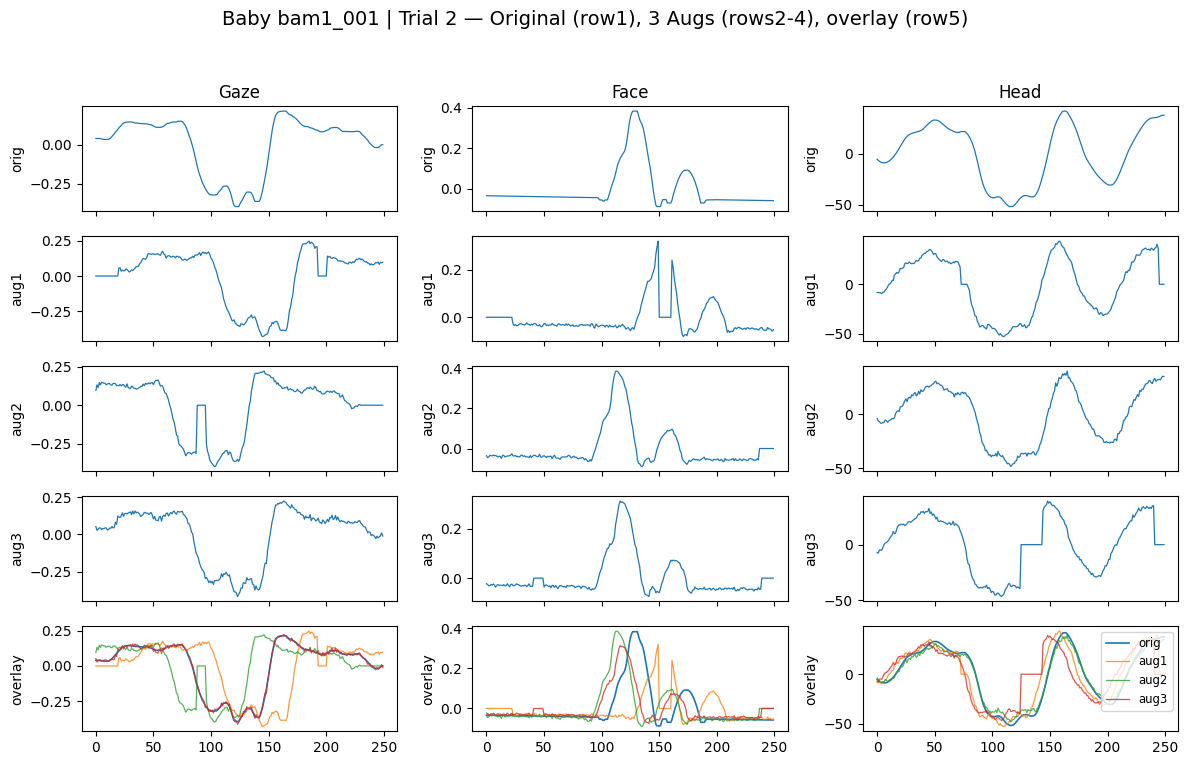

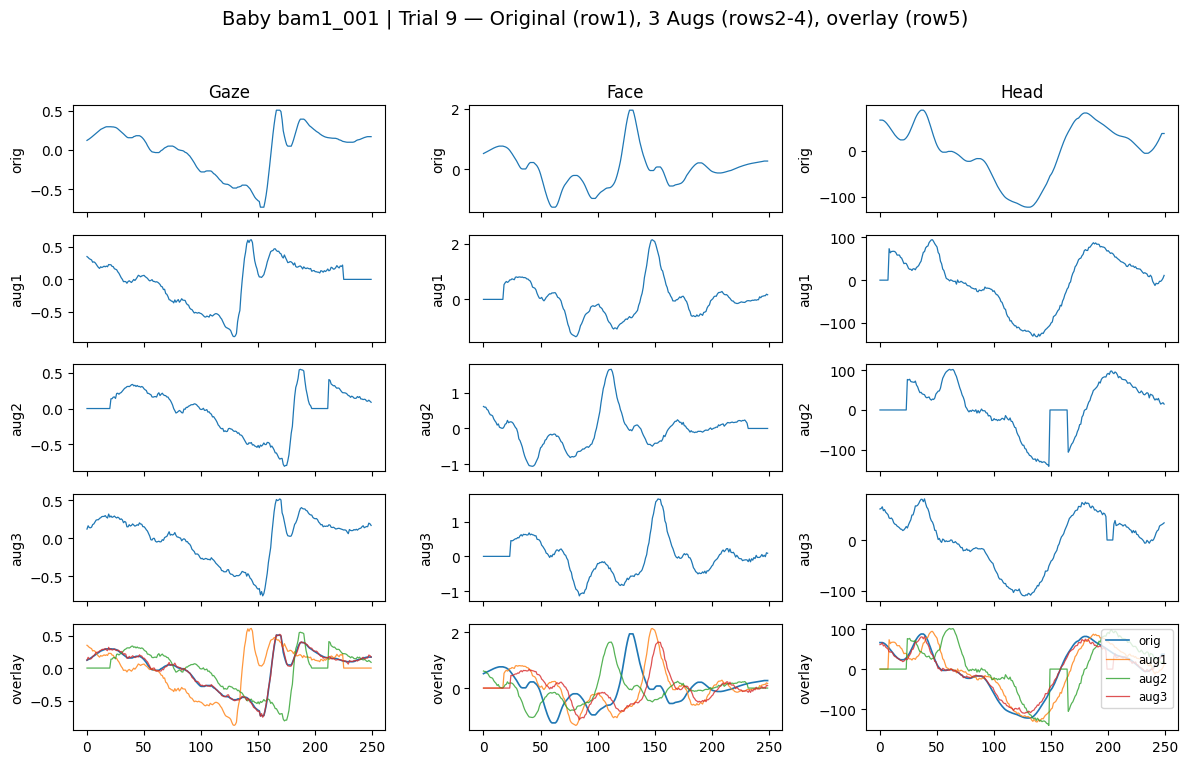

Done. Augmented dataset saved and report created.


In [25]:
# %% Create augmented dataset by copying OpenFaceInstance objects and renaming pt_id

# Output path (re-uses out_path if present, otherwise writes to working dir)
if 'out_path' in globals():
    OUT_PATH = Path(out_path)
else:
    # default to project working_dir if available, else current folder
    try:
        base_dir = Path(dataset.working_dir)
    except Exception:
        base_dir = Path('.')
    OUT_PATH = base_dir / f"{dataset.dataset_name}_aug.pkl"

OUT_DIR = OUT_PATH.parent
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Safety checks
if dataset is None:
    raise RuntimeError("Variable `dataset` not found. Load your BoaOpenFaceDataset first.")

# helper: ensure trial window length
def ensure_length(X, target_len=TARGET_LEN):
    T, D = X.shape
    if T == target_len:
        return X.copy()
    if T < target_len:
        pad = np.zeros((target_len - T, D), dtype=X.dtype)
        return np.vstack([X, pad])
    # initial crop
    return X[:target_len].copy()

# list to hold augmented instances
augmented_instances = []

# We'll also build a small report structure
report_rows = []

# iterate original instances and create augmented copies where needed
orig_count = 0
aug_count = 0
for inst in dataset.instances:
    orig_count += 1
    # mark original as not augmented (safer to set attribute)
    try:
        inst.is_augmented = False
    except Exception:
        # if instance class disallows new attrs, skip attribute setting (rare)
        pass

    if int(inst.trial_type) == 0:  # negative: augment
        # build base arrays (use raw attributes, no preprocessing)
        gaze = np.asarray(inst.gaze_info)
        head = np.asarray(inst.head_info)
        face = np.asarray(inst.face_info)

        # Ensure each modality window has TARGET_LEN time dimension (if needed)
        # Note: if your code concatenates modalities differently, keeping modality shapes is enough;
        # we only ensure each modality preserves length or gets padded/truncated consistently.
        if gaze.shape[0] != TARGET_LEN or head.shape[0] != TARGET_LEN or face.shape[0] != TARGET_LEN:
            gaze = ensure_length(gaze, TARGET_LEN)
            head = ensure_length(head, TARGET_LEN)
            face = ensure_length(face, TARGET_LEN)

        # create augmented copies
        for k in range(1, NEG_AUG_PER_TRIAL + 1):
            # deep-copy instance so we keep all attributes
            inst_aug = copy.deepcopy(inst)
            # apply augmentation to each modality (augment_negative should be in scope)
            # Note: augment_negative expects a combined array [T,D] but we can apply independently per modality
            gaze_aug = augment_negative(gaze)
            head_aug = augment_negative(head)
            face_aug = augment_negative(face)

            # assign augmented arrays back
            inst_aug.gaze_info = gaze_aug
            inst_aug.head_info = head_aug
            inst_aug.face_info = face_aug

            # rename pt_id to clearly mark augmented samples
            orig_pid = str(inst.pt_id)
            new_pid = f"{orig_pid}_aug{k}"
            inst_aug.pt_id = new_pid

            # optionally mark aug index and flag
            inst_aug.aug_idx = k
            try:
                inst_aug.is_augmented = True
            except Exception:
                pass

            # add to list
            augmented_instances.append(inst_aug)
            aug_count += 1

    else:
        # positives: optionally create light augmentations
        if POS_AUG_PER_TRIAL > 0:
            gaze = np.asarray(inst.gaze_info)
            head = np.asarray(inst.head_info)
            face = np.asarray(inst.face_info)
            if gaze.shape[0] != TARGET_LEN or head.shape[0] != TARGET_LEN or face.shape[0] != TARGET_LEN:
                gaze = ensure_length(gaze, TARGET_LEN)
                head = ensure_length(head, TARGET_LEN)
                face = ensure_length(face, TARGET_LEN)
            for k in range(1, POS_AUG_PER_TRIAL + 1):
                inst_aug = copy.deepcopy(inst)
                inst_aug.gaze_info = augment_positive(gaze)
                inst_aug.head_info = augment_positive(head)
                inst_aug.face_info = augment_positive(face)
                orig_pid = str(inst.pt_id)
                new_pid = f"{orig_pid}_augpos{k}"
                inst_aug.pt_id = new_pid
                inst_aug.aug_idx = k
                try:
                    inst_aug.is_augmented = True
                except Exception:
                    pass
                augmented_instances.append(inst_aug)
                aug_count += 1

# summary
print(f"Original instances: {orig_count}; Created augmented instances: {aug_count}")

# Build new dataset object as deep copy, but replace instances
dataset_aug = copy.deepcopy(dataset)
dataset_aug.dataset_name = f"{dataset.dataset_name}_aug"
# combine original instances + augmented instances
dataset_aug.instances = list(dataset.instances) + augmented_instances

# update ids list
try:
    dataset_aug.ids = np.unique([inst.pt_id for inst in dataset_aug.instances])
except Exception:
    # fallback: set ids attribute without np.unique
    dataset_aug.ids = [inst.pt_id for inst in dataset_aug.instances]

# Don't automatically compute stats (may produce files). If you want:
# dataset_aug.compute_statistics()

# Save the augmented dataset as the same structure as original (pickle)
with open(OUT_PATH, 'wb') as f:
    pickle.dump(dataset_aug, f)
print(f"Saved augmented dataset to: {OUT_PATH}")

# ---------- Save a small report CSV in the same folder ----------
# count per pt original and augmented
from collections import defaultdict
counts = defaultdict(lambda: {'orig':0, 'aug':0})
for inst in dataset.instances:
    counts[str(inst.pt_id)]['orig'] += 1
for inst in augmented_instances:
    # original pt is before suffix
    pid = str(inst.pt_id)
    # new pid is like 'bam1_001_aug3' -> extract original part
    orig_pid = pid.split('_aug')[0]
    counts[orig_pid]['aug'] += 1

report_rows = []
for pid, v in counts.items():
    report_rows.append({'pt_id': pid, 'orig_count': v['orig'], 'aug_count': v['aug'], 'total_after': v['orig'] + v['aug']})
report_df = pd.DataFrame(report_rows).sort_values(['total_after'], ascending=False)
report_csv = OUT_DIR / f"{dataset.dataset_name}_augmentation_report.csv"
report_df.to_csv(report_csv, index=False)
print("Saved augmentation report to:", report_csv)
print(report_df.head(20).to_string(index=False))

# ---------- Optional visualization: 5x3 per baby as you specified ----------
# (re-uses plotting code you used before, but now instances are actual OpenFaceInstance objects)
import matplotlib.pyplot as plt
from collections import defaultdict

# Create mapping by original trial (original pt/trial) => all windows (original + augmented copies)
by_orig_trial = defaultdict(list)
# include originals flagged (we set is_augmented=False earlier)
for inst in dataset.instances:
    key = (str(inst.pt_id), inst.trial_id)
    by_orig_trial[key].append({'inst': inst, 'is_aug': False})

# include augmented instances: their pt_id has _aug suffix; map back to orig pt id
for inst in augmented_instances:
    # augmented instance has pt_id like 'bam1_001_aug3' or 'bam1_001_augpos1' for pos
    aug_pid = str(inst.pt_id)
    if '_aug' in aug_pid:
        orig_pid = aug_pid.split('_aug')[0]
    else:
        orig_pid = aug_pid
    key = (orig_pid, inst.trial_id)
    by_orig_trial[key].append({'inst': inst, 'is_aug': True})

# find negative trials that have >=3 augmented variants
candidates = []
for key, lst in by_orig_trial.items():
    # find negative originals
    # ensure any original exists and label is 0
    origs = [x for x in lst if (not x['is_aug']) and int(x['inst'].trial_type) == 0]
    augs = [x for x in lst if x['is_aug'] and int(x['inst'].trial_type) == 0]
    if len(origs) >= 1 and len(augs) >= 3:
        candidates.append((key, origs, augs))

# plot up to two babies as before
n_plot_babies = 2
plotted = 0
for (key, origs, augs) in candidates:
    if plotted >= n_plot_babies:
        break
    pt, trialid = key
    orig_inst = origs[0]['inst']
    # take first 3 augmented insts
    aug_insts = [a['inst'] for a in augs[:3]]

    # extract modality dims from original instance
    gaze_dim = np.asarray(orig_inst.gaze_info).shape[1]
    head_dim = np.asarray(orig_inst.head_info).shape[1]
    face_dim = np.asarray(orig_inst.face_info).shape[1]
    total_dim = gaze_dim + head_dim + face_dim
    idx_gaze = (0, gaze_dim)
    idx_head = (gaze_dim, gaze_dim + head_dim)
    idx_face = (gaze_dim + head_dim, total_dim)

    # helper to get modality time series (first channel)
    def get_modality_ts_from_inst(inst_obj, modality):
        gaze = np.asarray(inst_obj.gaze_info)
        head = np.asarray(inst_obj.head_info)
        face = np.asarray(inst_obj.face_info)
        # ensure they are length TARGET_LEN
        gaze = ensure_length(gaze, TARGET_LEN)
        head = ensure_length(head, TARGET_LEN)
        face = ensure_length(face, TARGET_LEN)
        if modality == 'gaze':
            mat = gaze
        elif modality == 'face':
            mat = face
        elif modality == 'head':
            mat = head
        else:
            raise ValueError(modality)
        # return first channel
        return mat[:, 0] if mat.shape[1] >= 1 else mat[:, 0]

    # build 5x3 grid
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 1.6*nrows), sharex=True)
    fig.suptitle(f"Baby {pt} | Trial {trialid} — Original (row1), 3 Augs (rows2-4), overlay (row5)", fontsize=14)

    modalities = ['gaze', 'face', 'head']
    # row 1: original
    for col_idx, modality in enumerate(modalities):
        ax = axes[0, col_idx]
        ts = get_modality_ts_from_inst(orig_inst, modality)
        ax.plot(ts, lw=0.9)
        if col_idx == 0:
            ax.set_title('Gaze')
        elif col_idx == 1:
            ax.set_title('Face')
        else:
            ax.set_title('Head')
        ax.set_ylabel('orig')

    # rows 2-4: augmentations
    for r in range(3):
        aug_inst = aug_insts[r]
        for col_idx, modality in enumerate(modalities):
            ax = axes[r+1, col_idx]
            ts = get_modality_ts_from_inst(aug_inst, modality)
            ax.plot(ts, lw=0.9)
            ax.set_ylabel(f'aug{r+1}')

    # row 5 overlay
    for col_idx, modality in enumerate(modalities):
        ax = axes[4, col_idx]
        ts_orig = get_modality_ts_from_inst(orig_inst, modality)
        ax.plot(ts_orig, lw=1.2, label='orig')
        for r in range(3):
            ts_aug = get_modality_ts_from_inst(aug_insts[r], modality)
            ax.plot(ts_aug, lw=0.9, alpha=0.8, label=f'aug{r+1}')
        if col_idx == ncols-1:
            ax.legend(loc='upper right', fontsize='small')
        ax.set_ylabel('overlay')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    plotted += 1

print("Done. Augmented dataset saved and report created.")
